0.027000000000000003
-8142.702702702705 10942.702702702705
loading [0.027000000000000003, 0.0455, 0.064, 0.08929999999999999, 0.0993, 0.10729999999999999]
bearings F 0x, 0z, 1x, 1z: -8142.702702702705 -12214.054054054057 10942.702702702705 16414.054054054057
max moment: 232.44989072916343
failed moment: 226.14017599710144
ultimate stress 572000000
r/d 0.10344827586206896
D/d 1.035344827586207

first number is the bearing sruface, second is the notch, static
stress concetration KT, KF: 1.5 1.365866841985494
bending stress, Pa (static, will be completely reveresd) 97493644.20217602 160638473.01372623
axial stress 7899274.012975284 8765054.836944962
shear stress x,z, x,z 5820517.693771262 8730776.540656893 6458461.458801551 9687692.188202325
radial stress (from press fit) -78077258.34623551 

--von mises stress Static: 210244740.16311988 
--FOS Static: 2.3924498639525718

von mises stress no loading: 85228664.31622094 
FOS with no side loading (for calculations): 5.90177030269695
50.0
cyc

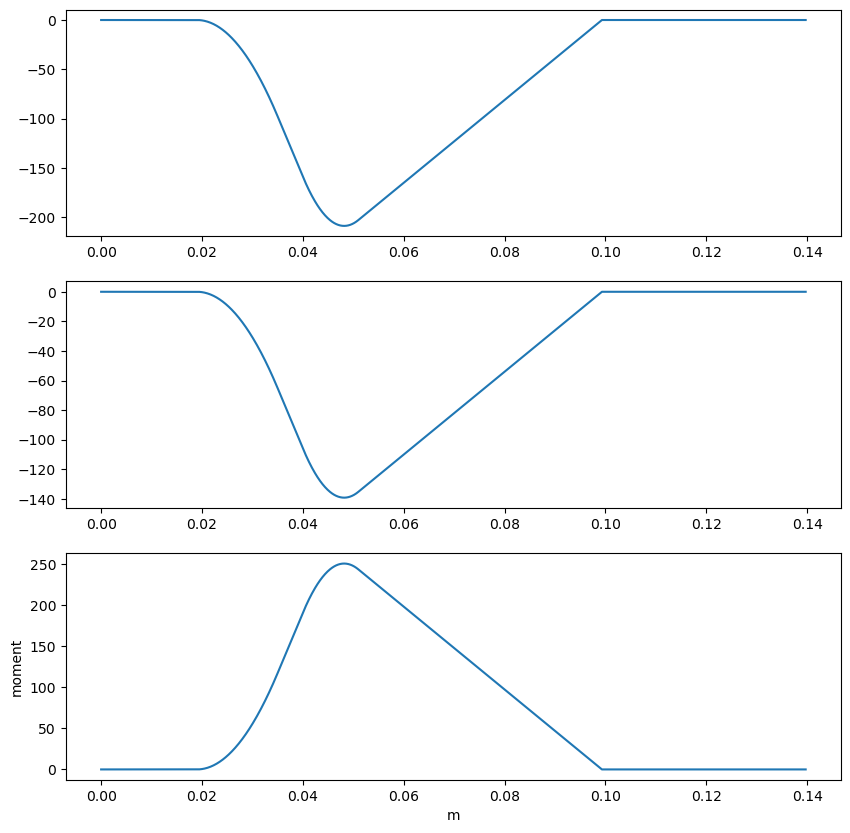

In [1]:
#corner + breaking
import numpy as np
from sympy import symbols,solve
import matplotlib.pyplot as plt


b0=16/1000 #width of first bearing
b1=(16-5)/1000 #width of second bearing
#Skf 7206 BE-2RZP  For 𝑑=30−50mm d=30−50mm: tΔdmp=0 to −12μm https://www.skf.com/group/products/rolling-bearings/ball-bearings/angular-contact-ball-bearings/single-row-angular-contact-ball-bearings/productid-7206%20BE-2RZP

br=(15-.006)/1000 #radius of the bearing

ri0=8.5/1000 #inside radius
ri1=20/1000#changes at load 3
ep=.025/1000 #tolerancing + on shaft
r0=15.0/1000 +ep/2 #radius of the shaft (combined with br to get interfereance fit)
d0= r0*2

d01=29/1000 #finding the radius for stress concentrations
r01= d01/2


r02= 3/1000 #variables for farther along the shaft not needed since i am not calculating torsion and other forces
r2=42.49/1000
d21=54/1000
r21=d21/2
r3=40/1000
r4=27.44/1000
d5=48/1000
r5=d5/2

dist=[53.25/1000,54.5/1000,56/1000,61/1000,67/1000,87.3/1000,91.3/1000,107.3/1000,139.7/1000] #from left, failure was at dist[1]
load=[dist[2]-.005-.008-.016,dist[2]-.008-.005/2,(dist[3]+dist[4])/2,(dist[5]+dist[6])/2,(dist[6]+dist[7])/2,dist[7]]

#load 0,1 is bearing loading fixed,
     #2 is the brake caliper torsion,
     #3 is wheel lugs torision, 
     #4 is veritacal and lateral wheel forces
     #5 is wheel nut axial loading

f0r="radial from bearing"
f1r=f0r


#loading in Newtons
f4x=2800#braking logitudal load
f4z=4200# summ of braking and cornering, not realistic since tire will slipp before this load, still doing it as sum to factor in
f5y=3800#corning lateral load
t23= 355# brake disk torsion, not applied in this study

x, MM, MYi, MZi= np.empty(1398),np.empty(1398),np.empty(1398),np.empty(1398)

def sing(spot,dist): #singularity equation 
    if dist < spot:
        return 0
    else:
        #print(dist)
        return (dist-spot)
def const(spot,dist,bearing):
    if dist- bearing/2 > spot:
        return (dist-spot)
    if dist+bearing/2 < spot:
        return 0
    else:
        #print(dist)
        return (dist-spot+.5*bearing)/(bearing)*(dist+bearing/2-spot)*.5

#linear algebra to find the force at the distances for x and z
Ax=[[1,1],
    [load[0],load[1]]]
Bx=[f4x,f4x*load[4]]
print(load[0])
f0x,f1x=np.linalg.solve(Ax,Bx)
print(f0x,f1x)
Az=[[1,1],
    [load[0],load[1]]]
Bz=[f4z,f4z*load[4]]
f0z,f1z=np.linalg.solve(Az,Bz)

print("loading",load)
print("bearings F 0x, 0z, 1x, 1z:",f0x,f0z,f1x,f1z)

#functions for the moments calculations
def funcs(X):
    #print(distance, dist)
    EQMX = f0x*const(load[0],X,b0) + f1x*const(load[1],X,b1) - f4x* sing(load[4],X)
    EQMZ = f0z*const(load[0],X,b0) + f1z*const(load[1],X,b1) - f4z* sing(load[4],X)
    Mm= (EQMX**2 + EQMZ**2)**(1/2)
    #print (Mm)
    return EQMX,EQMZ,Mm

#difference between max moment and the failed moment is the stress concentration number
#bending around x and z axis
MX,MZ,Mm0=funcs(dist[0])
print("max moment:",Mm0)
MX,MZ,Mm1=funcs(dist[1])
print("failed moment:",Mm1)

for i in range(1398):
    x[i] = (i)/10000
    MZ,MY,Mm=funcs(x[i])
    MM[i]=Mm
    MZi[i]=MZ
    MYi[i]=MY

#figures of graphs
fig1,axs1 = plt.subplots(3,figsize=(10,10))
plt.xlabel("m")
plt.ylabel("moment")
line1=axs1[0].plot(x,MYi,label='Moment in Y')


plt.xlabel("m")
plt.ylabel("moment")
line2=axs1[1].plot(x,MZi,label='Moment in Z')


plt.xlabel("m")
plt.ylabel("moment")
line3=axs1[2].plot(x,MM,label='Total Moment')






#loading conditions for fatigue
I0=(r0**4-ri0**4)*np.pi/4
I1=(r01**4-ri0**4)*np.pi/4

ob0=Mm0*r0/I0
ob1=Mm1*r01/I1

#material properties
#https://asm.matweb.com/search/SpecificMaterial.asp?bassnum=MA7075T6
E=71.7*10**9
Sut= 572000000
Sy= 503000000
print("ultimate stress", Sut)


#kf factors taken from the graph (shigly 320)
Kt=1.5 #A-15-14
q= 1/(1+.635/(r02*1000)**(1/2))
Kf= 1+ q*(Kt-1)
print("r/d",r02/d01)
print("D/d",r0/r01)
print("\nfirst number is the bearing sruface, second is the notch, static")
print("stress concetration KT, KF:", Kt, Kf)
print("bending stress, Pa (static, will be completely reveresd)",ob0,ob1*Kt)


#axial
A0=(r0**2-ri0**2)*np.pi
A1=(r01**2-ri0**2)*np.pi
oa0=f5y/A0
oa1=f5y/A1
print("axial stress", oa0,oa1)

T0x=f4x/A0
T0z=f4z/A0
T1x=f4x/A1
T1z=f4z/A1
print("shear stress x,z, x,z",T0x,T0z,T1x,T1z)


#radial (shigly 140)
#steel properties https://www.astmsteel.com/product/52100-bearing-steel-aisi/
Estl=210*10**9
r= (br+r0)/2 #avg radius
o = (br-r0)*2 #dist between
v=.33
vstl=.29
    
P = o/((r/Estl *((r**2+.031**2)/(.031**2-r**2)+vstl)
          +r/E *((r**2+ri0**2)/(r**2-ri0**2)-v)))
#print(P)
orad= P
print("radial stress (from press fit)",orad, "\n")



#von mises
ov= (((Kt*ob1-orad)**2+(oa1-Kt*ob1)**2+(orad-oa1)**2+6*(T1x**2+T1z**2))/2)**(1/2)
print("--von mises stress Static:",ov, "\n--FOS Static:", Sy/ov)

ovmean= (((0-orad)**2+(oa1-0)**2+(orad-oa1)**2+6*(T1x**2+T1z**2))/2)**(1/2)
print("\nvon mises stress no loading:",ovmean, "\nFOS with no side loading (for calculations):", Sy/ovmean)

#fatigue, completely reversed
#Kohout and Vechet funciton for fatigue limit of cycles
#asumptions probalby high, but this was on 2 seperate cars since it ogt repressed
hrs=2.5 #hard cornering+ breaking constant
mph= 20 #avg
miles=mph*hrs
print(miles)
Td= .406
mile= 1609
distance=miles*mile
cycles=2*distance/(np.pi*Td)
print("cycles:",cycles)

#source for fatigue curve:
# o(N)= oinf ((N+B)/(N+C))^b from https://komunikacie.uniza.sk/pdfs/csl/2009/01/03.pdf
Se = 145200000*((cycles+480.5)/(cycles+1532411.8))**(-0.1787)
print("endurance limit at cycles",Se, "\n")

#goodman
ngood=(ovmean/Sut+ob1*Kf/Se)**(-1)
print("--goodman fatigure:",ngood)

#gerber
ngerber=1/2*(Sut/ovmean)**2*(ob1*Kf/Se)* (-1+(1+((2*ovmean*Se)/(Sut*Kf*ob1))**2)**(1/2))
print("--gerber fatigure:", ngerber)

print("this will overestimate fatigure since it combines the 2 max loadings simultaneously (more than the tire grip)")

### Changes:
- von mises stress Static: 210244740.16311988  
- FOS Static: 2.3924498639525718
- goodman fatigure:  1.2736474544434502
- gerber fatigure:  1.49406330955694


## Max case (slight overestimated forces):

- max moment: 232.44989072916343
- failed moment: 226.1401759971014
- bending stress 258181027.00569245
- axial stress 12599766.32810838
- shear stress x,z5 9284038.347027227 13926057.52054084
- radial stress -189556549.79157
- cycles: 126147.93272653181
- endurance limit at cycles 229937728.0498020

### Broken part:
- von mises stress Static: 389440008.2785119 
- FOS Static: 1.29159816481997044
- goodman fatigure: 0.6838569020658325
- gerber fatigure: 0.8233326916827

## Changes

---

### Solid shafts:
- von mises stress Static: 362817550.9405328 
- FOS Static: 1.38637174165382
- goodman fatigure: 0.8783227439091601
- gerber fatigure: 1.074464072988271
  
---

### ID=18mm:
- von mises stress Static: 317683766.49901325 
- FOS Static: 1.5833355463618326
- goodman fatigure: 0.7489359839194795
- gerber fatigure: 0.908861272065995411
  
---

### H7s6 interference:

- von mises stress Static: 318201795.0719611 
- FOS Static: 1.580757895744261
- goodman fatigure: 0.7643027012713487
- gerber fatigure: 0.871083800961915
  
---

### H7p6 interference:

- von mises stress Static: 301921757.2396967 
- FOS Static: 1.665994543085103
- goodman fatigure: 0.7868417091890502
- gerber fatigure: 0.879631693622674
  
---

### No notch, same KT:

- von mises stress Static: 332563168.5048826 
- FOS Static: 1.51249461045658
- goodman fatigure: 0.848552161807385
- gerber fatigure: 1.043397598120115
  
---

### No notch, changing fillet stress concentration KT=1.5:

- von mises stress Static: 304090504.0583773 
- FOS Static: 1.654112816043204
- goodman fatigure: 0.9684015431122067
- gerber fatigure: 1.202983015054324
  
---

### No notch, changing fillet stress concentration KT=1.4:

- von mises stress Static: 295433542.56300855 
- FOS Static: 1.702582569454593
- goodman fatigure: 1.013117991437225
- gerber fatigure: 1.2617118621102021
  
---

### No notch, same KT, H7p6, Solid: (panic change to)

- von mises stress Static: 199825911.07038394 
- FOS Static: 2.517191075499864
- goodman fatigure: 1.2469189671769867
- gerber fatigure: 1.4375615779127
  
---

### No notch, KT=1.4, H7s6, 18mm ID: (proposed for next year)

- von mises stress Static: 205266796.72292075 
- FOS Static: 2.450469379511847
- goodman fatigure: 1.2864598685967346
- gerber fatigure: 1.5475917835579445
  
--- 
## Photos

### Drawings:

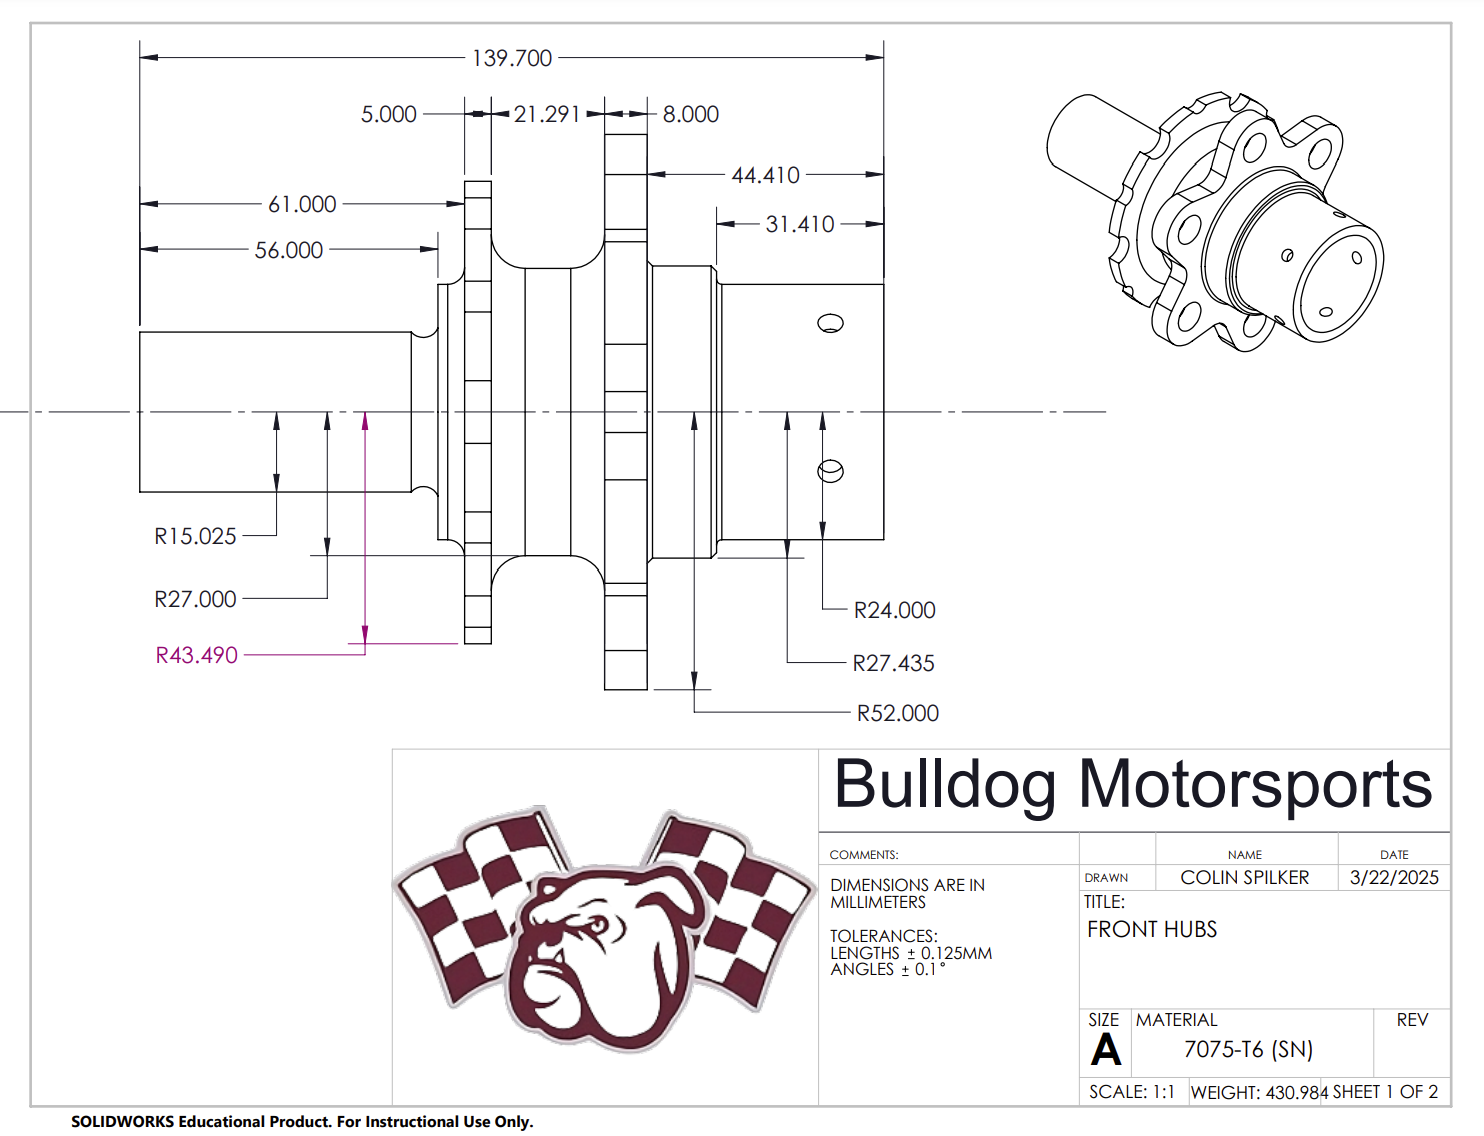
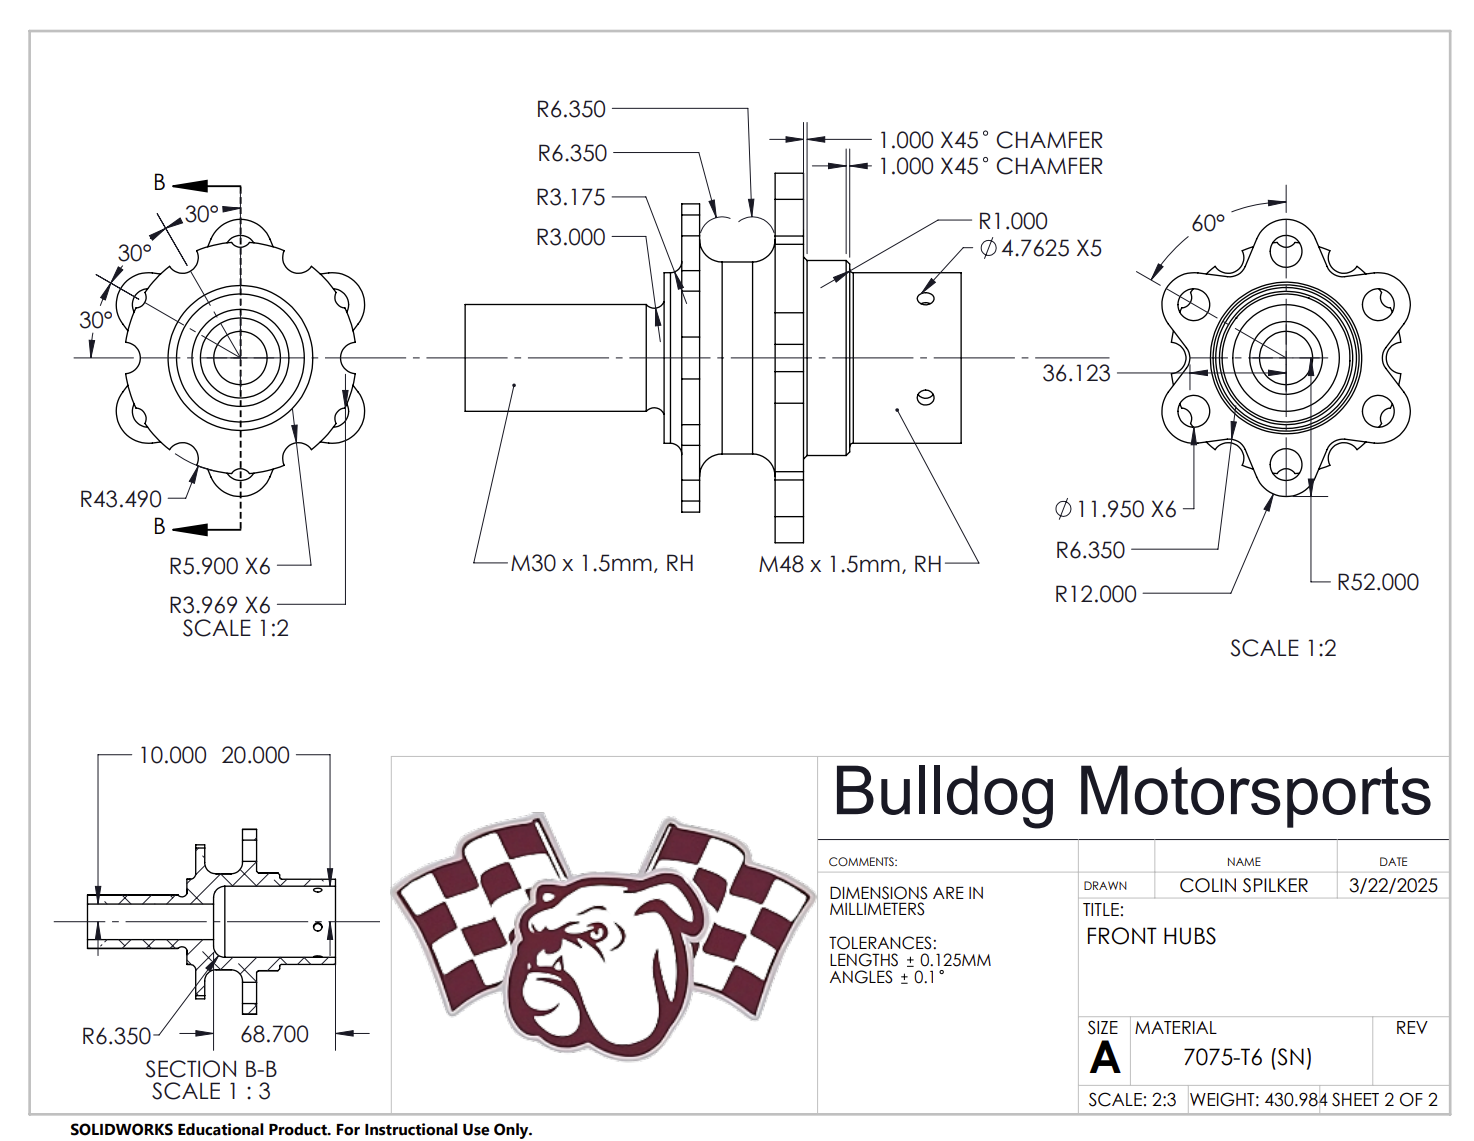
### Current Kt chart:
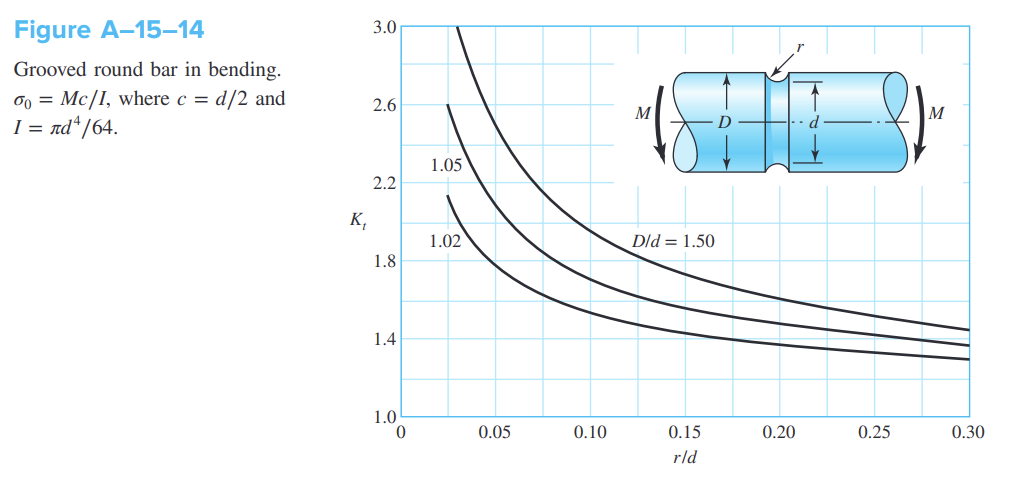
### Proposed Kt chart:
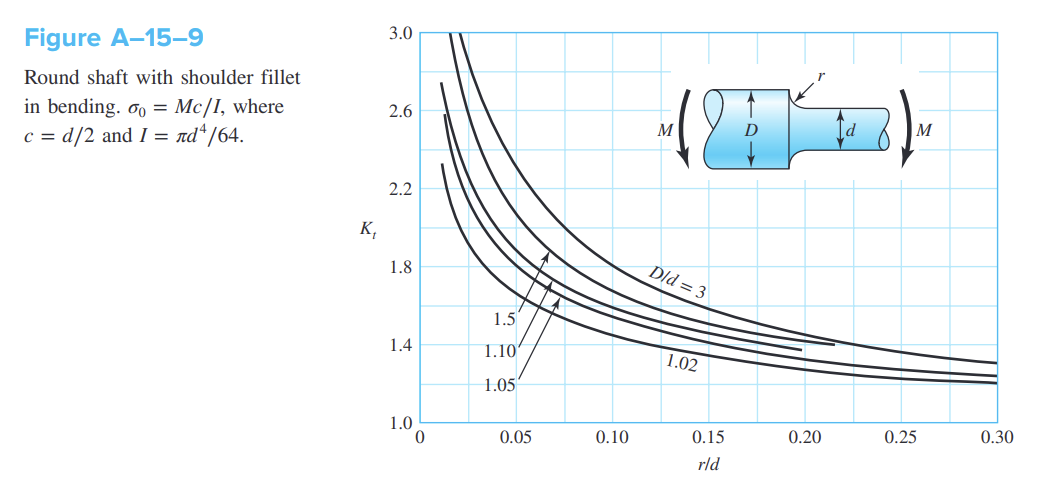
### S-N curve for 7075 fatigue: https://komunikacie.uniza.sk/pdfs/csl/2009/01/03.pdf
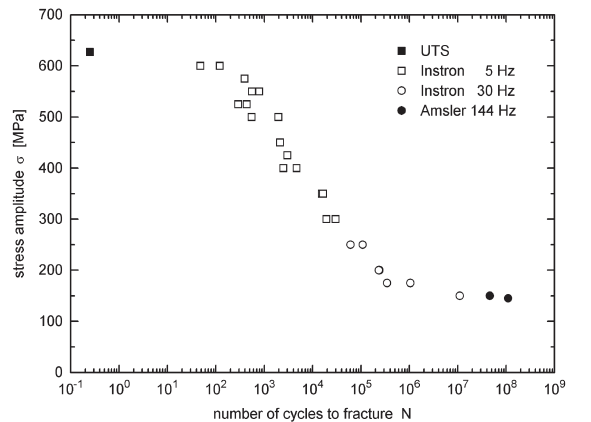.png)
435428546

8599704
4